In [15]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from pathlib import Path
import numpy as np
import sys
import importlib
import matplotlib.pyplot as plt

In [5]:
PROJECT_ROOT = Path().resolve().parent

sys.path.append(str(PROJECT_ROOT / "src"))

import model_utils
importlib.reload(model_utils)
from model_utils import run_nested_cv

In [ ]:
sample_fp = PROJECT_ROOT / "outputs" / "sample_points_indices.csv"
samples = pd.read_csv(sample_fp)

samples = samples.dropna(subset="lc")

pred_cols = ['B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B8', 'NDVI', 'NDWI', 'MNDWI', 'NDCI', 'NDMI', 'NDBI', 'NDAVI']
metadata_cols = ["label_id","location","class_int", "class_label","obs_date"]


y = samples['lc'].values # values gives you numpy array
X = samples[pred_cols].values
metadata = samples[metadata_cols]
groups = samples['location'].values 


In [33]:


pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier())
])

param_grid = {
    'model__n_estimators': [100,200,500], # have to prefix the keys with the pipeline stepname followed by __
    'model__max_depth': [3,5,10,20,None],
    'model__min_samples_leaf': [1, 5, 10]
    }

results_df, predictions_df = run_nested_cv(X, y, groups, metadata, pipe, param_grid, n_jobs= 4)

predictions_fp = PROJECT_ROOT / "outputs" / "nested_cv_predictions.csv"
predictions_df.to_csv(predictions_fp)
results_fp = PROJECT_ROOT / "outputs"/ "nested_cv_results.csv"
results_df.to_csv(results_fp)


F1 Binary:  0.917 +/- 0.031
F1 Macro:   0.915 +/- 0.034
Accuracy:   0.915 +/- 0.034


In [34]:
results_df

,test_location,f1,f1_macro,accuracy,best_n_estimators,best_max_depth,best_min_samples_leaf,train_f1,train_f1_macro,train_accuracy,f1_gap,f1_macro_gap,accuracy_gap
0,Hartbeespoort,0.951943,0.953675,0.953740,200,5,10,0.935230,0.934576,0.934582,-0.016712,-0.019100,-0.019158
1,Inle,0.926139,0.922807,0.922951,100,5,10,0.938123,0.937480,0.937487,0.011984,0.014673,0.014536
2,Mula,0.892894,0.899217,0.899614,500,5,1,0.942299,0.941921,0.941923,0.049406,0.042703,0.042309
3,RawaPening,0.945110,0.945055,0.945055,200,5,5,0.935220,0.935007,0.935007,-0.009890,-0.010048,-0.010047
4,Rodman,0.894667,0.881493,0.882958,200,20,10,0.962562,0.962366,0.962367,0.067895,0.080872,0.079409
5,Valsequillo,0.941935,0.942638,0.942647,500,5,1,0.935916,0.935616,0.935618,-0.006020,-0.007022,-0.007029
6,Vembanad,0.926390,0.926573,0.926573,200,5,5,0.937522,0.936563,0.936577,0.011132,0.009990,0.010004
7,Winam,0.856068,0.846303,0.846923,100,5,1,0.941101,0.941013,0.941013,0.085033,0.094710,0.094089


In [ ]:
predictions_fp = PROJECT_ROOT / "outputs" / "nested_cv_predictions.csv"

predictions_df = pd.read_csv(predictions_fp, index_col=0) 
predictions_df.head()

,y_true,y_pred,label_id,location,lc,class_int,obs_date
5831,1,1,HA0001_20210121,Hartbeespoort,1,3,2021-01-21
5832,1,1,HA0002_20210121,Hartbeespoort,1,3,2021-01-21
5833,1,1,HA0003_20210121,Hartbeespoort,1,3,2021-01-21
5834,1,1,HA0004_20210121,Hartbeespoort,1,3,2021-01-21
5835,1,1,HA0005_20210121,Hartbeespoort,1,3,2021-01-21


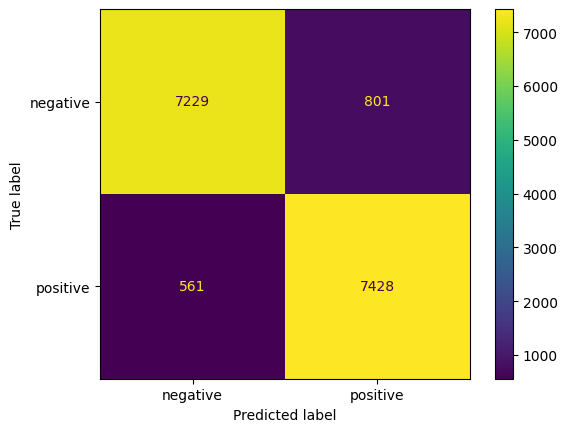

In [12]:
conf_matrix = confusion_matrix(predictions_df["y_true"], predictions_df["y_pred"])

conf_m_disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["negative","positive"] )
conf_m_disp.plot()
plt.show()

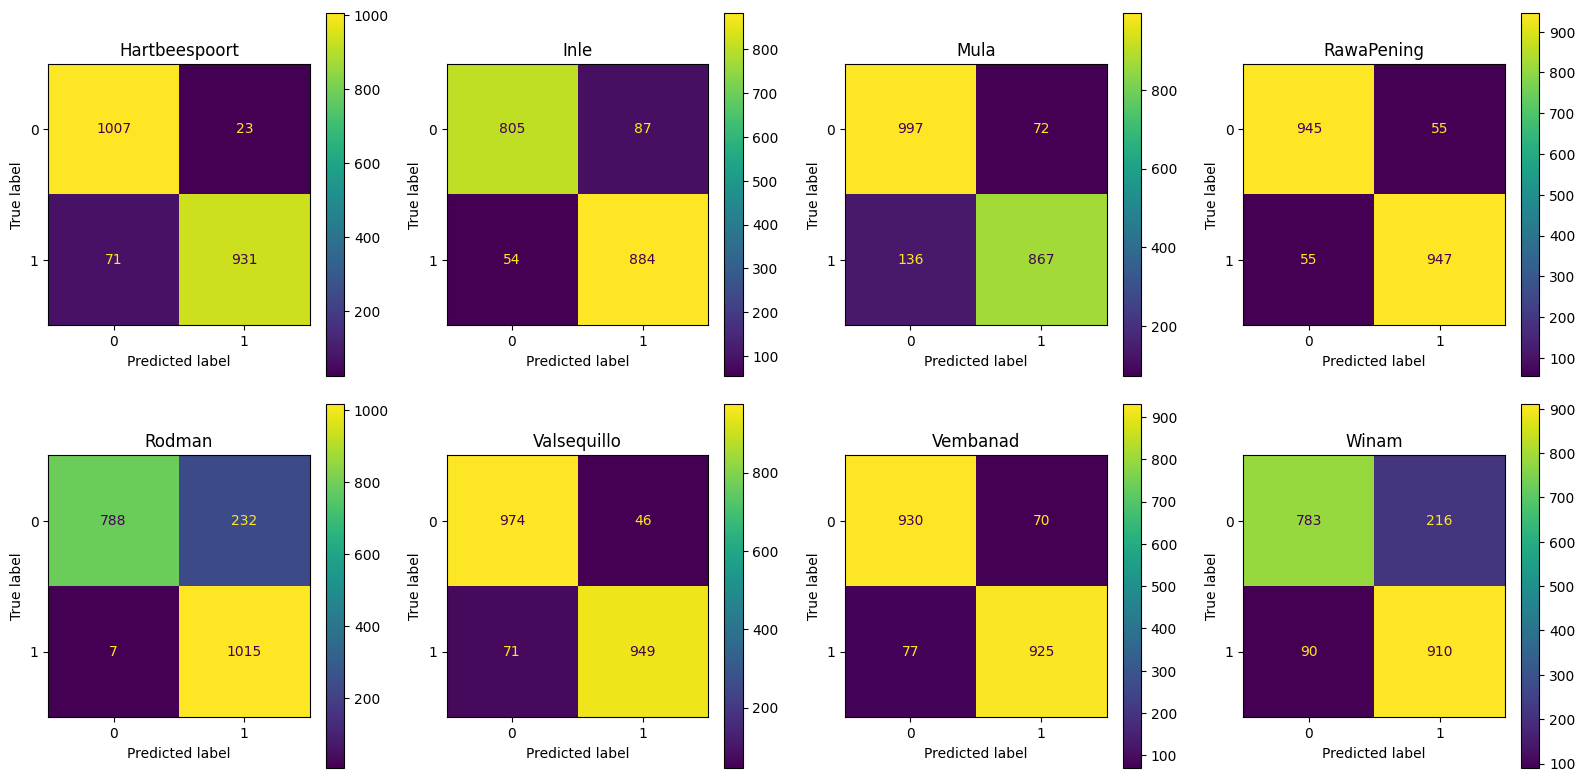

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))  # adjust grid to number of locations
axes = axes.flatten()

for ax, (location, group) in zip(axes, predictions_df.groupby('location')):
    cm = confusion_matrix(group['y_true'], group['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1'])
    disp.plot(ax=ax)
    ax.set_title(location)

plt.tight_layout()
plt.show()

In [20]:
for location, group in predictions_df.groupby('location'):
    print(f"\n{location}")
    print(pd.crosstab(group['class_int'], group['y_pred'], normalize='index'))


Hartbeespoort
y_pred            0         1
class_int                    
1          0.984283  0.015717
2          0.995455  0.004545
3          0.070858  0.929142
4          0.839506  0.160494

Inle
y_pred            0         1
class_int                    
1          0.787805  0.212195
2          1.000000  0.000000
3          0.057569  0.942431

Mula
y_pred            0         1
class_int                    
1          0.875000  0.125000
2          1.000000  0.000000
3          0.135593  0.864407

RawaPening
y_pred            0         1
class_int                    
1          0.894118  0.105882
2          0.997959  0.002041
3          0.054890  0.945110

Rodman
y_pred            0         1
class_int                    
1          0.571977  0.428023
2          0.981964  0.018036
3          0.006849  0.993151

Valsequillo
y_pred            0         1
class_int                    
1          0.956432  0.043568
2          1.000000  0.000000
3          0.069608  0.930392
4         